<a href="https://colab.research.google.com/github/vTrindadev/GlucoMonitorIA/blob/main/GlicoMonitorIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# instala a biblioteca oficial do Gemini
!pip install -q -U google-genai

In [ ]:
# biblioteca para acessar variáveis do sistema
import os

# biblioteca para trabalhar com tabelas
import pandas as pd

# biblioteca para cálculos numéricos
import numpy as np

# biblioteca para gerar gráficos
import matplotlib.pyplot as plt

# biblioteca do Colab para acessar Secrets
from google.colab import userdata

# cliente oficial do Gemini
from google import genai

In [ ]:
# pega a chave salva no painel Secrets do Colab
api_key = userdata.get("FESA_API_KEY")

# define a chave no nome esperado pela biblioteca do Gemini
os.environ["GEMINI_API_KEY"] = api_key

# confirmação
print("API Key configurada com sucesso.")

API Key configurada com sucesso.


In [ ]:
# cria o cliente do Gemini
client = genai.Client()

# confirmação
print("Conexão com Gemini pronta.")

Conexão com Gemini pronta.


In [ ]:
# dicionário com os dados do usuário
usuario = {
    "nome": "Victor",
    "idade": 22,
    "peso": 75,
    "altura": 1.75,   # em metros
    "sexo": "Masculino",
    "colesterol": 190,
    "observacoes": "Monitoramento acadêmico com inserções manuais"
}

# mostra os dados cadastrados
usuario

{'nome': 'Victor',
 'idade': 22,
 'peso': 75,
 'altura': 1.75,
 'sexo': 'Masculino',
 'colesterol': 190,
 'observacoes': 'Monitoramento acadêmico com inserções manuais'}

In [ ]:
# calcula o IMC com base no peso e altura
imc = usuario["peso"] / (usuario["altura"] ** 2)

# salva o IMC no cadastro do usuário
usuario["imc"] = round(imc, 2)

# exibe resumo do usuário
print("Nome:", usuario["nome"])
print("Idade:", usuario["idade"])
print("Peso:", usuario["peso"])
print("Altura:", usuario["altura"])
print("IMC:", usuario["imc"])
print("Colesterol:", usuario["colesterol"])

Nome: Victor
Idade: 22
Peso: 75
Altura: 1.75
IMC: 24.49
Colesterol: 190


In [ ]:
# parâmetros que o sistema vai usar para interpretar as leituras
parametros_monitoramento = {
    "glicose_min": 70,              # limite inferior
    "glicose_max": 140,             # limite superior
    "limite_subida_brusca": 30,     # subida brusca
    "limite_queda_brusca": -30      # queda brusca
}

# mostra os parâmetros
parametros_monitoramento

{'glicose_min': 70,
 'glicose_max': 140,
 'limite_subida_brusca': 30,
 'limite_queda_brusca': -30}

In [ ]:
# cria um DataFrame vazio para receber as leituras do usuário
dados = pd.DataFrame(columns=["horario", "glicose", "evento"])

# mostra a tabela vazia
dados

,horario,glicose,evento


In [ ]:
# função para adicionar uma nova leitura
def adicionar_leitura(df, horario, glicose, evento):
    nova_linha = pd.DataFrame({
        "horario": [horario],
        "glicose": [glicose],
        "evento": [evento]
    })

    df = pd.concat([df, nova_linha], ignore_index=True)

    return df

In [ ]:
# adiciona leituras simulando o uso do sistema
dados = adicionar_leitura(dados, "08:00", 92, "jejum")
dados = adicionar_leitura(dados, "10:00", 110, "lanche")
dados = adicionar_leitura(dados, "12:00", 155, "almoço")
dados = adicionar_leitura(dados, "14:00", 138, "repouso")
dados = adicionar_leitura(dados, "16:00", 74, "atividade física")
dados = adicionar_leitura(dados, "18:00", 95, "lanche")
dados = adicionar_leitura(dados, "20:00", 165, "jantar")
dados = adicionar_leitura(dados, "22:00", 142, "repouso")

# mostra as leituras registradas
dados

,horario,glicose,evento
0,08:00,92,jejum
1,10:00,110,lanche
2,12:00,155,almoço
3,14:00,138,repouso
4,16:00,74,atividade física
5,18:00,95,lanche
6,20:00,165,jantar
7,22:00,142,repouso


In [ ]:
# calcula a diferença de uma leitura para a anterior
dados["variacao"] = dados["glicose"].diff()

# mostra a tabela atualizada
dados

,horario,glicose,evento,variacao
0,08:00,92,jejum,NaN
1,10:00,110,lanche,18
2,12:00,155,almoço,45
3,14:00,138,repouso,-17
4,16:00,74,atividade física,-64
5,18:00,95,lanche,21
6,20:00,165,jantar,70
7,22:00,142,repouso,-23


In [ ]:
# função para classificar a glicose em faixas
def classificar_faixa_glicose(valor):
    # se for menor que 70
    if valor < 70:
        return "Hipoglicemia"

    # se estiver entre 70 e 140
    elif 70 <= valor <= 140:
        return "Faixa normal"

    # se for maior que 140
    else:
        return "Hiperglicemia"

In [ ]:
# aplica a função em todas as leituras
dados["faixa_glicemica"] = dados["glicose"].apply(classificar_faixa_glicose)

# mostra a tabela
dados

,horario,glicose,evento,variacao,faixa_glicemica
0,08:00,92,jejum,NaN,Faixa normal
1,10:00,110,lanche,18,Faixa normal
2,12:00,155,almoço,45,Hiperglicemia
3,14:00,138,repouso,-17,Faixa normal
4,16:00,74,atividade física,-64,Faixa normal
5,18:00,95,lanche,21,Faixa normal
6,20:00,165,jantar,70,Hiperglicemia
7,22:00,142,repouso,-23,Hiperglicemia


In [ ]:
# sistema especialista com regras rígidas SE/ENTÃO
def sistema_especialista_personalizado(glicose_atual, variacao, parametros):
    # valores padrão
    estado = "Indefinido"
    alerta = "Sem alerta"
    regras_ativadas = []

    # pega os parâmetros configurados
    glicose_min = parametros["glicose_min"]
    glicose_max = parametros["glicose_max"]
    limite_subida = parametros["limite_subida_brusca"]
    limite_queda = parametros["limite_queda_brusca"]

    # regra 1: glicose abaixo do mínimo
    if glicose_atual < glicose_min:
        estado = "Hipoglicemia"
        alerta = "Alerta crítico"
        regras_ativadas.append(f"Regra 1: glicose abaixo de {glicose_min}")

    # regra 2: glicose dentro da faixa normal
    elif glicose_min <= glicose_atual <= glicose_max:
        estado = "Faixa normal"
        alerta = "Sem alerta"
        regras_ativadas.append(f"Regra 2: glicose entre {glicose_min} e {glicose_max}")

    # regra 3: glicose acima do máximo
    elif glicose_atual > glicose_max:
        estado = "Hiperglicemia"
        alerta = "Atenção"
        regras_ativadas.append(f"Regra 3: glicose acima de {glicose_max}")

    # regra 4: subida brusca
    if pd.notna(variacao) and variacao > limite_subida:
        regras_ativadas.append(f"Regra 4: subida brusca acima de {limite_subida}")

    # regra 5: queda brusca
    if pd.notna(variacao) and variacao < limite_queda:
        regras_ativadas.append(f"Regra 5: queda brusca abaixo de {limite_queda}")

    # retorna o resultado técnico
    return estado, alerta, regras_ativadas

In [ ]:
# listas para guardar os resultados
estados = []
alertas = []
regras = []

# percorre cada linha da tabela
for _, linha in dados.iterrows():
    # aplica o sistema especialista na leitura atual
    estado, alerta, regras_ativadas = sistema_especialista_personalizado(
        linha["glicose"],
        linha["variacao"],
        parametros_monitoramento
    )

    # salva os resultados nas listas
    estados.append(estado)
    alertas.append(alerta)
    regras.append(" | ".join(regras_ativadas))

# adiciona os resultados na tabela
dados["estado_especialista"] = estados
dados["alerta"] = alertas
dados["regras_ativadas"] = regras

# mostra a tabela final
dados

,horario,glicose,evento,variacao,faixa_glicemica,estado_especialista,alerta,regras_ativadas
0,08:00,92,jejum,NaN,Faixa normal,Faixa normal,Sem alerta,Regra 2: glicose entre 70 e 140
1,10:00,110,lanche,18,Faixa normal,Faixa normal,Sem alerta,Regra 2: glicose entre 70 e 140
2,12:00,155,almoço,45,Hiperglicemia,Hiperglicemia,Atenção,Regra 3: glicose acima de 140 | Regra 4: subid...
3,14:00,138,repouso,-17,Faixa normal,Faixa normal,Sem alerta,Regra 2: glicose entre 70 e 140
4,16:00,74,atividade física,-64,Faixa normal,Faixa normal,Sem alerta,Regra 2: glicose entre 70 e 140 | Regra 5: que...
5,18:00,95,lanche,21,Faixa normal,Faixa normal,Sem alerta,Regra 2: glicose entre 70 e 140
6,20:00,165,jantar,70,Hiperglicemia,Hiperglicemia,Atenção,Regra 3: glicose acima de 140 | Regra 4: subid...
7,22:00,142,repouso,-23,Hiperglicemia,Hiperglicemia,Atenção,Regra 3: glicose acima de 140


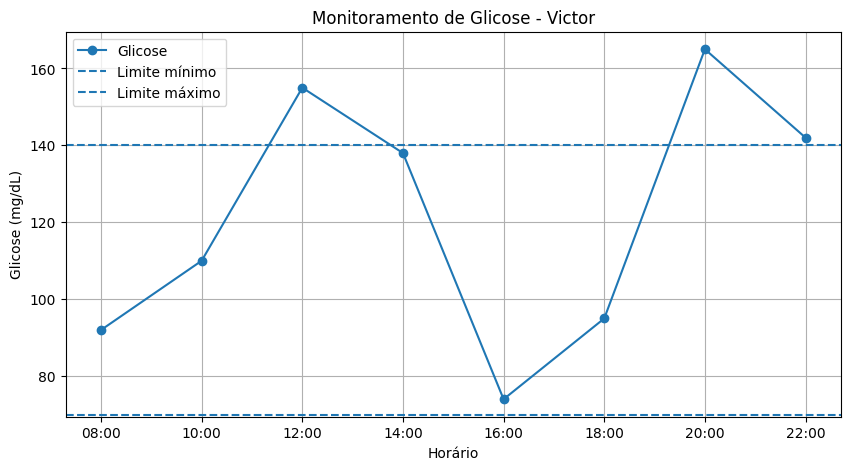

In [ ]:
# cria o gráfico de linha do monitoramento
plt.figure(figsize=(10,5))
plt.plot(dados["horario"], dados["glicose"], marker="o", label="Glicose")

# adiciona linhas horizontais com os limites
plt.axhline(parametros_monitoramento["glicose_min"], linestyle="--", label="Limite mínimo")
plt.axhline(parametros_monitoramento["glicose_max"], linestyle="--", label="Limite máximo")

# título e rótulos
plt.title(f"Monitoramento de Glicose - {usuario['nome']}")
plt.xlabel("Horário")
plt.ylabel("Glicose (mg/dL)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# calcula estatísticas básicas
media = dados["glicose"].mean()
maximo = dados["glicose"].max()
minimo = dados["glicose"].min()

# imprime resultados
print(f"Média da glicose: {media:.2f} mg/dL")
print(f"Máximo da glicose: {maximo:.2f} mg/dL")
print(f"Mínimo da glicose: {minimo:.2f} mg/dL")

Média da glicose: 121.38 mg/dL
Máximo da glicose: 165.00 mg/dL
Mínimo da glicose: 74.00 mg/dL


In [ ]:
# pega a última leitura do monitoramento
ultima_leitura = dados.iloc[-1]

# mostra os dados da última leitura
print("Horário:", ultima_leitura["horario"])
print("Glicose:", ultima_leitura["glicose"])
print("Evento:", ultima_leitura["evento"])
print("Variação:", ultima_leitura["variacao"])
print("Estado:", ultima_leitura["estado_especialista"])
print("Alerta:", ultima_leitura["alerta"])
print("Regras ativadas:", ultima_leitura["regras_ativadas"])

Horário: 22:00
Glicose: 142
Evento: repouso
Variação: -23
Estado: Hiperglicemia
Alerta: Atenção
Regras ativadas: Regra 3: glicose acima de 140


In [ ]:
# cria o texto que será enviado ao Gemini
prompt_gemini = f"""
Você é um assistente de análise interpretativa em saúde.

Importante:
- Não tome a decisão técnica.
- Não altere a classificação.
- Apenas interprete a saída do Sistema Especialista.

Dados do usuário:
- Nome: {usuario['nome']}
- Idade: {usuario['idade']}
- IMC: {usuario['imc']}
- Colesterol: {usuario['colesterol']}

Saída técnica:
- Horário: {ultima_leitura['horario']}
- Glicose: {ultima_leitura['glicose']} mg/dL
- Evento: {ultima_leitura['evento']}
- Variação: {ultima_leitura['variacao']}
- Estado: {ultima_leitura['estado_especialista']}
- Alerta: {ultima_leitura['alerta']}
- Regras ativadas: {ultima_leitura['regras_ativadas']}

Explique em linguagem natural:
1. Por que essa decisão foi tomada.
2. Quais alertas são importantes.
3. Quais cuidados ou acompanhamentos podem ser sugeridos.
4. Não substitua avaliação médica.
"""

# mostra o prompt montado
print(prompt_gemini)


Você é um assistente de análise interpretativa em saúde.

Importante:
- Não tome a decisão técnica.
- Não altere a classificação.
- Apenas interprete a saída do Sistema Especialista.

Dados do usuário:
- Nome: Victor
- Idade: 22
- IMC: 24.49
- Colesterol: 190

Saída técnica:
- Horário: 22:00
- Glicose: 142 mg/dL
- Evento: repouso
- Variação: -23
- Estado: Hiperglicemia
- Alerta: Atenção
- Regras ativadas: Regra 3: glicose acima de 140

Explique em linguagem natural:
1. Por que essa decisão foi tomada.
2. Quais alertas são importantes.
3. Quais cuidados ou acompanhamentos podem ser sugeridos.
4. Não substitua avaliação médica.



In [ ]:
# envia o prompt para o Gemini
resposta = client.models.generate_content(
    model="gemini-3-flash-preview",
    contents=prompt_gemini
)

# imprime a interpretação gerada
print(resposta.text)

Olá, Victor. Como assistente de análise interpretativa, preparei uma explicação em linguagem natural sobre os resultados apresentados pelo Sistema Especialista.

Aqui está a interpretação dos seus dados:

### 1. Por que essa decisão foi tomada?
A classificação de **Hiperglicemia** foi definida porque o sistema identificou que o seu nível de glicose no sangue (142 mg/dL) está acima do limite estabelecido para o seu estado atual de repouso. O sistema utilizou a **Regra 3**, que é ativada automaticamente sempre que o valor da glicose ultrapassa 140 mg/dL. Mesmo que tenha ocorrido uma queda de 23 unidades em relação à medição anterior (variação de -23), o valor absoluto ainda permanece superior ao que é considerado ideal para o período noturno em repouso.

### 2. Quais alertas são importantes?
*   **Estado de Hiperglicemia:** Isso significa que há uma concentração elevada de açúcar no sangue no momento do registro (22:00).
*   **Alerta de Atenção:** O sistema sinaliza que este valor não de

In [ ]:
# salva o texto em uma variável
interpretacao_gemini = resposta.text

# exibe a interpretação salva
print(interpretacao_gemini)

Olá, Victor. Como assistente de análise interpretativa, preparei uma explicação em linguagem natural sobre os resultados apresentados pelo Sistema Especialista.

Aqui está a interpretação dos seus dados:

### 1. Por que essa decisão foi tomada?
A classificação de **Hiperglicemia** foi definida porque o sistema identificou que o seu nível de glicose no sangue (142 mg/dL) está acima do limite estabelecido para o seu estado atual de repouso. O sistema utilizou a **Regra 3**, que é ativada automaticamente sempre que o valor da glicose ultrapassa 140 mg/dL. Mesmo que tenha ocorrido uma queda de 23 unidades em relação à medição anterior (variação de -23), o valor absoluto ainda permanece superior ao que é considerado ideal para o período noturno em repouso.

### 2. Quais alertas são importantes?
*   **Estado de Hiperglicemia:** Isso significa que há uma concentração elevada de açúcar no sangue no momento do registro (22:00).
*   **Alerta de Atenção:** O sistema sinaliza que este valor não de

In [ ]:
# imprime um resumo técnico + interpretativo
print("===== RESUMO FINAL =====")
print(f"Usuário: {usuario['nome']}")
print(f"Último horário: {ultima_leitura['horario']}")
print(f"Glicose: {ultima_leitura['glicose']} mg/dL")
print(f"Estado: {ultima_leitura['estado_especialista']}")
print(f"Alerta: {ultima_leitura['alerta']}")
print(f"Regras: {ultima_leitura['regras_ativadas']}")
print("\n===== INTERPRETAÇÃO DO GEMINI =====")
print(interpretacao_gemini)

===== RESUMO FINAL =====
Usuário: Victor
Último horário: 22:00
Glicose: 142 mg/dL
Estado: Hiperglicemia
Alerta: Atenção
Regras: Regra 3: glicose acima de 140

===== INTERPRETAÇÃO DO GEMINI =====
Olá, Victor. Como assistente de análise interpretativa, preparei uma explicação em linguagem natural sobre os resultados apresentados pelo Sistema Especialista.

Aqui está a interpretação dos seus dados:

### 1. Por que essa decisão foi tomada?
A classificação de **Hiperglicemia** foi definida porque o sistema identificou que o seu nível de glicose no sangue (142 mg/dL) está acima do limite estabelecido para o seu estado atual de repouso. O sistema utilizou a **Regra 3**, que é ativada automaticamente sempre que o valor da glicose ultrapassa 140 mg/dL. Mesmo que tenha ocorrido uma queda de 23 unidades em relação à medição anterior (variação de -23), o valor absoluto ainda permanece superior ao que é considerado ideal para o período noturno em repouso.

### 2. Quais alertas são importantes?
*   

In [ ]:
# função que adiciona uma nova leitura e recalcula toda a análise
def atualizar_monitoramento(df_monitoramento, horario, glicose, evento, parametros):
    # adiciona a nova leitura
    df_monitoramento = adicionar_leitura(df_monitoramento, horario, glicose, evento)

    # recalcula a variação
    df_monitoramento["variacao"] = df_monitoramento["glicose"].diff()

    # recalcula a faixa glicêmica
    df_monitoramento["faixa_glicemica"] = df_monitoramento["glicose"].apply(classificar_faixa_glicose)

    # listas para guardar nova análise
    estados = []
    alertas = []
    regras = []

    # reaplica o sistema especialista em todas as leituras
    for _, linha in df_monitoramento.iterrows():
        estado, alerta, regras_ativadas = sistema_especialista_personalizado(
            linha["glicose"],
            linha["variacao"],
            parametros
        )
        estados.append(estado)
        alertas.append(alerta)
        regras.append(" | ".join(regras_ativadas))

    # atualiza as colunas
    df_monitoramento["estado_especialista"] = estados
    df_monitoramento["alerta"] = alertas
    df_monitoramento["regras_ativadas"] = regras

    # retorna a tabela atualizada
    return df_monitoramento

In [ ]:
dados = atualizar_monitoramento(
    dados,
    "23:00",
    62,
    "teste manual",
    parametros_monitoramento
)

dados

,horario,glicose,evento,variacao,faixa_glicemica,estado_especialista,alerta,regras_ativadas
0,08:00,92,jejum,NaN,Faixa normal,Faixa normal,Sem alerta,Regra 2: glicose entre 70 e 140
1,10:00,110,lanche,18,Faixa normal,Faixa normal,Sem alerta,Regra 2: glicose entre 70 e 140
2,12:00,155,almoço,45,Hiperglicemia,Hiperglicemia,Atenção,Regra 3: glicose acima de 140 | Regra 4: subid...
3,14:00,138,repouso,-17,Faixa normal,Faixa normal,Sem alerta,Regra 2: glicose entre 70 e 140
4,16:00,74,atividade física,-64,Faixa normal,Faixa normal,Sem alerta,Regra 2: glicose entre 70 e 140 | Regra 5: que...
5,18:00,95,lanche,21,Faixa normal,Faixa normal,Sem alerta,Regra 2: glicose entre 70 e 140
6,20:00,165,jantar,70,Hiperglicemia,Hiperglicemia,Atenção,Regra 3: glicose acima de 140 | Regra 4: subid...
7,22:00,142,repouso,-23,Hiperglicemia,Hiperglicemia,Atenção,Regra 3: glicose acima de 140
8,23:00,62,teste manual,-80,Hipoglicemia,Hipoglicemia,Alerta crítico,Regra 1: glicose abaixo de 70 | Regra 5: queda...


In [ ]:
# pega novamente a última leitura após a inserção manual
ultima_leitura = dados.iloc[-1]

# mostra os dados atualizados
print("Horário:", ultima_leitura["horario"])
print("Glicose:", ultima_leitura["glicose"])
print("Evento:", ultima_leitura["evento"])
print("Variação:", ultima_leitura["variacao"])
print("Estado:", ultima_leitura["estado_especialista"])
print("Alerta:", ultima_leitura["alerta"])
print("Regras ativadas:", ultima_leitura["regras_ativadas"])

Horário: 23:00
Glicose: 62
Evento: teste manual
Variação: -80
Estado: Hipoglicemia
Alerta: Alerta crítico
Regras ativadas: Regra 1: glicose abaixo de 70 | Regra 5: queda brusca abaixo de -30


In [ ]:
# cria um novo prompt com a leitura mais recente
prompt_gemini = f"""
Você é um assistente de análise interpretativa em saúde.

Importante:
- Não tome a decisão técnica.
- Não altere a classificação.
- Apenas interprete a saída do Sistema Especialista.

Dados do usuário:
- Nome: {usuario['nome']}
- Idade: {usuario['idade']}
- IMC: {usuario['imc']}
- Colesterol: {usuario['colesterol']}

Saída técnica:
- Horário: {ultima_leitura['horario']}
- Glicose: {ultima_leitura['glicose']} mg/dL
- Evento: {ultima_leitura['evento']}
- Variação: {ultima_leitura['variacao']}
- Estado: {ultima_leitura['estado_especialista']}
- Alerta: {ultima_leitura['alerta']}
- Regras ativadas: {ultima_leitura['regras_ativadas']}

Explique em linguagem natural:
1. Por que essa decisão foi tomada.
2. Quais alertas são importantes.
3. Quais cuidados ou acompanhamentos podem ser sugeridos.
4. Não substitua avaliação médica.
"""

# envia novamente ao Gemini
resposta = client.models.generate_content(
    model="gemini-3-flash-preview",
    contents=prompt_gemini
)

# mostra a nova interpretação
print(resposta.text)

Olá, Victor. Como assistente de análise, vou interpretar os dados fornecidos pelo sistema para que você compreenda o que essa leitura de glicose significa no momento.

Aqui está a interpretação dos resultados:

### 1. Por que essa decisão foi tomada?
O sistema classificou seu estado atual como **Hipoglicemia** e emitiu um **alerta crítico** devido à combinação de dois fatores principais identificados pelas regras automáticas:
*   **Valor absoluto (Regra 1):** Sua glicose foi registrada em **62 mg/dL**, o que está abaixo do limite de segurança padrão (geralmente 70 mg/dL).
*   **Velocidade da queda (Regra 5):** Houve uma variação negativa de **-80 mg/dL**. Isso indica que seu nível de açúcar no sangue caiu muito rapidamente em um curto espaço de tempo, o que o sistema identifica como uma situação de instabilidade que exige atenção imediata.

### 2. Quais alertas são importantes?
*   **Alerta Crítico:** Este é o nível mais alto de atenção do sistema. Ele não ignora apenas o valor baixo, 

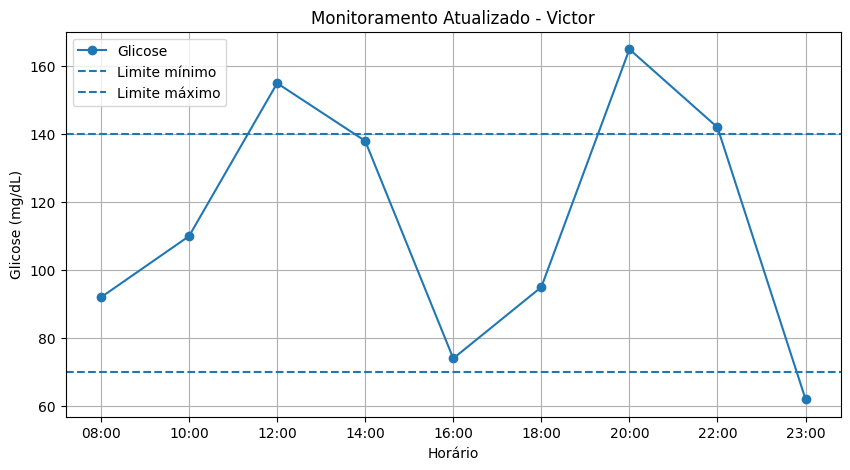

In [ ]:
# plota novamente o gráfico com a nova leitura incluída
plt.figure(figsize=(10,5))
plt.plot(dados["horario"], dados["glicose"], marker="o", label="Glicose")
plt.axhline(parametros_monitoramento["glicose_min"], linestyle="--", label="Limite mínimo")
plt.axhline(parametros_monitoramento["glicose_max"], linestyle="--", label="Limite máximo")

plt.title(f"Monitoramento Atualizado - {usuario['nome']}")
plt.xlabel("Horário")
plt.ylabel("Glicose (mg/dL)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print("""
Conclusão:
O projeto foi estruturado como um sistema de monitoramento glicêmico personalizado.
O usuário pode se cadastrar, informar seus parâmetros e inserir leituras manuais.
A decisão técnica é feita por um Sistema Especialista baseado em regras SE/ENTÃO.
A API do Gemini atua como camada interpretativa, explicando os resultados em linguagem natural.
""")


Conclusão:
O projeto foi estruturado como um sistema de monitoramento glicêmico personalizado.
O usuário pode se cadastrar, informar seus parâmetros e inserir leituras manuais.
A decisão técnica é feita por um Sistema Especialista baseado em regras SE/ENTÃO.
A API do Gemini atua como camada interpretativa, explicando os resultados em linguagem natural.



# Etapa 3 — Inteligência Evolutiva com Rede Neural Artificial

Nesta etapa, o projeto GlucoMonitorIA recebeu uma camada de aprendizado de máquina utilizando uma Rede Neural Artificial.

A abordagem escolhida foi a Opção A — Redes Neurais Artificiais, pois o objetivo do sistema é prever o comportamento glicêmico futuro do usuário com base nos dados coletados pelos sensores e registros históricos.

Diferente da Etapa 2, em que o sistema utilizava regras especialistas para classificar a situação do paciente, nesta etapa a RNA aprende padrões nos dados e estima a próxima glicose. Essa previsão é então enviada ao Sistema Especialista, que classifica o risco e gera uma recomendação.

O Gemini continua sendo utilizado apenas como camada interpretativa, explicando em linguagem natural o resultado gerado pelo sistema.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# cria uma cópia dos dados atuais
dados_rna = dados.copy()

# remove espaços extras dos nomes das colunas
dados_rna.columns = dados_rna.columns.str.strip()

# mostra as colunas disponíveis
print(dados_rna.columns)

Index(['horario', 'glicose', 'evento', 'variacao', 'faixa_glicemica',
       'estado_especialista', 'alerta', 'regras_ativadas'],
      dtype='object')


In [ ]:
# cria uma cópia dos dados atuais
dados_rna = dados.copy()

# remove espaços extras dos nomes das colunas
dados_rna.columns = dados_rna.columns.str.strip()

# transforma hora em número
dados_rna["hora_num"] = dados_rna["horario"].astype(str).str[:2].astype(int)

# padroniza o texto do evento
dados_rna["evento"] = dados_rna["evento"].astype(str).str.lower().str.strip()

# transforma eventos em números
mapa_eventos = {
    "jejum": 0,
    "lanche": 1,
    "almoço": 2,
    "repouso": 3,
    "atividade física": 4,
    "jantar": 5,
    "teste manual": 6
}

dados_rna["evento_num"] = dados_rna["evento"].map(mapa_eventos)

# substitui valores não encontrados por 0
dados_rna["evento_num"] = dados_rna["evento_num"].fillna(0)

# substitui variação NaN por 0
dados_rna["variacao_glicose"] = dados_rna["variacao"].fillna(0)

dados_rna

/tmp/ipykernel_6664/2941443301.py:30: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dados_rna["variacao_glicose"] = dados_rna["variacao"].fillna(0)


,horario,glicose,evento,variacao,faixa_glicemica,estado_especialista,alerta,regras_ativadas,hora_num,evento_num,variacao_glicose
0,08:00,92,jejum,NaN,Faixa normal,Faixa normal,Sem alerta,Regra 2: glicose entre 70 e 140,8,0,0
1,10:00,110,lanche,18,Faixa normal,Faixa normal,Sem alerta,Regra 2: glicose entre 70 e 140,10,1,18
2,12:00,155,almoço,45,Hiperglicemia,Hiperglicemia,Atenção,Regra 3: glicose acima de 140 | Regra 4: subid...,12,2,45
3,14:00,138,repouso,-17,Faixa normal,Faixa normal,Sem alerta,Regra 2: glicose entre 70 e 140,14,3,-17
4,16:00,74,atividade física,-64,Faixa normal,Faixa normal,Sem alerta,Regra 2: glicose entre 70 e 140 | Regra 5: que...,16,4,-64
5,18:00,95,lanche,21,Faixa normal,Faixa normal,Sem alerta,Regra 2: glicose entre 70 e 140,18,1,21
6,20:00,165,jantar,70,Hiperglicemia,Hiperglicemia,Atenção,Regra 3: glicose acima de 140 | Regra 4: subid...,20,5,70
7,22:00,142,repouso,-23,Hiperglicemia,Hiperglicemia,Atenção,Regra 3: glicose acima de 140,22,3,-23
8,23:00,62,teste manual,-80,Hipoglicemia,Hipoglicemia,Alerta crítico,Regra 1: glicose abaixo de 70 | Regra 5: queda...,23,6,-80


In [ ]:
# detecta o nome correto da coluna de glicose
if "glicose_atual" in dados_rna.columns:
    col_glicose = "glicose_atual"
elif "glicose" in dados_rna.columns:
    col_glicose = "glicose"
else:
    raise Exception("Coluna de glicose não encontrada")

# cria o alvo
dados_rna["proxima_glicose"] = dados_rna[col_glicose].shift(-1)

# remove última linha
dados_treinamento = dados_rna.dropna(subset=["proxima_glicose"])

dados_treinamento

,horario,glicose,evento,variacao,faixa_glicemica,estado_especialista,alerta,regras_ativadas,hora_num,evento_num,variacao_glicose,proxima_glicose
0,08:00,92,jejum,NaN,Faixa normal,Faixa normal,Sem alerta,Regra 2: glicose entre 70 e 140,8,0,0,110
1,10:00,110,lanche,18,Faixa normal,Faixa normal,Sem alerta,Regra 2: glicose entre 70 e 140,10,1,18,155
2,12:00,155,almoço,45,Hiperglicemia,Hiperglicemia,Atenção,Regra 3: glicose acima de 140 | Regra 4: subid...,12,2,45,138
3,14:00,138,repouso,-17,Faixa normal,Faixa normal,Sem alerta,Regra 2: glicose entre 70 e 140,14,3,-17,74
4,16:00,74,atividade física,-64,Faixa normal,Faixa normal,Sem alerta,Regra 2: glicose entre 70 e 140 | Regra 5: que...,16,4,-64,95
5,18:00,95,lanche,21,Faixa normal,Faixa normal,Sem alerta,Regra 2: glicose entre 70 e 140,18,1,21,165
6,20:00,165,jantar,70,Hiperglicemia,Hiperglicemia,Atenção,Regra 3: glicose acima de 140 | Regra 4: subid...,20,5,70,142
7,22:00,142,repouso,-23,Hiperglicemia,Hiperglicemia,Atenção,Regra 3: glicose acima de 140,22,3,-23,62


In [ ]:
# variáveis de entrada
X = dados_treinamento[[
    "hora_num",
    "glicose",
    "variacao_glicose",
    "evento_num"
]]

# variável que queremos prever
y = dados_treinamento["proxima_glicose"]

print("Entradas da RNA:")
display(X)

print("Saída esperada:")
display(y)

Entradas da RNA:


,hora_num,glicose,variacao_glicose,evento_num
0,8,92,0,0
1,10,110,18,1
2,12,155,45,2
3,14,138,-17,3
4,16,74,-64,4
5,18,95,21,1
6,20,165,70,5
7,22,142,-23,3


Saída esperada:


,proxima_glicose
0,110
1,155
2,138
3,74
4,95
5,165
6,142
7,62


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_normalizado = scaler.fit_transform(X)

X_normalizado

array([[-1.52752523, -0.94882333, -0.15944928, -1.50679801],
       [-1.09108945, -0.3674167 ,  0.29976465, -0.87235674],
       [-0.65465367,  1.0860999 ,  0.98858555, -0.23791548],
       [-0.21821789,  0.53699363, -0.59315133,  0.39652579],
       [ 0.21821789, -1.53022997, -1.79220993,  1.03096706],
       [ 0.65465367, -0.85192223,  0.37630031, -0.87235674],
       [ 1.09108945,  1.40910359,  1.62638268,  1.66540833],
       [ 1.52752523,  0.66619511, -0.74622264,  0.39652579]])

In [ ]:
from sklearn.neural_network import MLPRegressor

modelo_rna = MLPRegressor(
    hidden_layer_sizes=(10, 10),
    activation="relu",
    solver="adam",
    max_iter=2000,
    random_state=42
)

modelo_rna.fit(X_normalizado, y)

print("Treinamento concluído com sucesso.")

Treinamento concluído com sucesso.


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


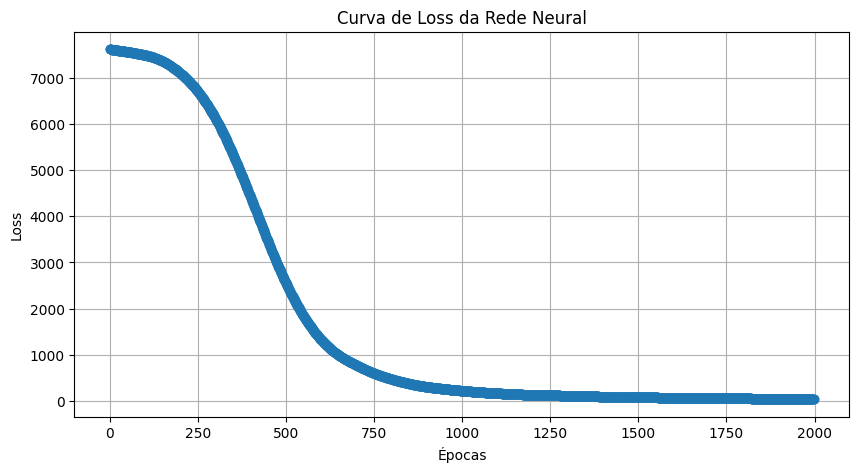

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(modelo_rna.loss_curve_, marker="o")
plt.title("Curva de Loss da Rede Neural")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

previsoes = modelo_rna.predict(X_normalizado)

mae = mean_absolute_error(y, previsoes)
mse = mean_squared_error(y, previsoes)
rmse = np.sqrt(mse)
r2 = r2_score(y, previsoes)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²:", round(r2, 2))

MAE: 5.41
RMSE: 9.13
R²: 0.93


In [ ]:
comparacao = pd.DataFrame({
    "Glicose real seguinte": y.values,
    "Glicose prevista pela RNA": previsoes.round(2)
})

comparacao

,Glicose real seguinte,Glicose prevista pela RNA
0,110,124.52
1,155,134.13
2,138,140.87
3,74,70.84
4,95,94.86
5,165,164.94
6,142,142.34
7,62,63.28


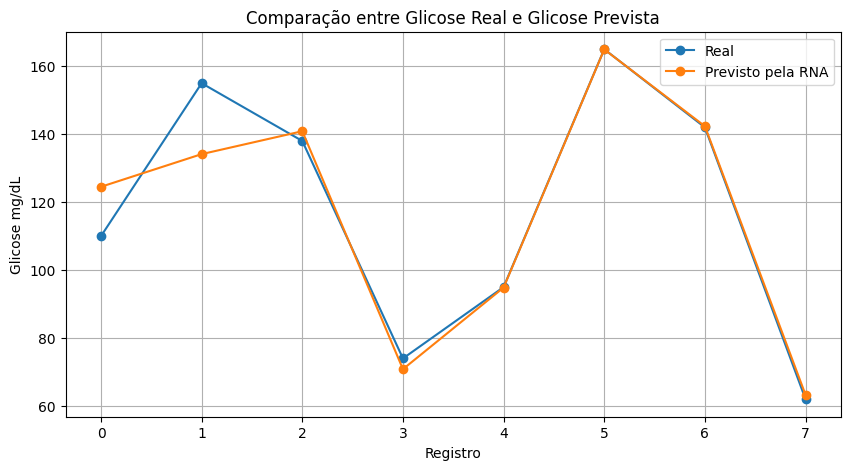

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(comparacao["Glicose real seguinte"].values, marker="o", label="Real")
plt.plot(comparacao["Glicose prevista pela RNA"].values, marker="o", label="Previsto pela RNA")
plt.title("Comparação entre Glicose Real e Glicose Prevista")
plt.xlabel("Registro")
plt.ylabel("Glicose mg/dL")
plt.legend()
plt.grid(True)
plt.show()

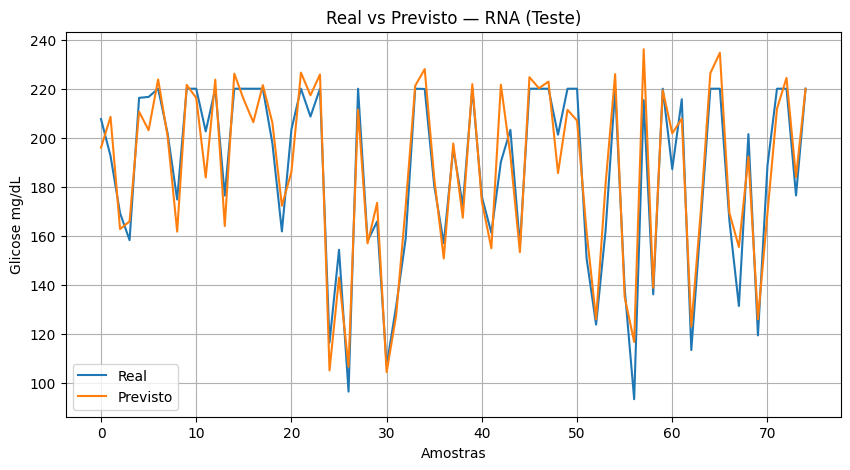

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(y_teste.values, label="Real")
plt.plot(previsoes_teste, label="Previsto")

plt.title("Real vs Previsto — RNA (Teste)")
plt.xlabel("Amostras")
plt.ylabel("Glicose mg/dL")
plt.legend()
plt.grid(True)

plt.show()

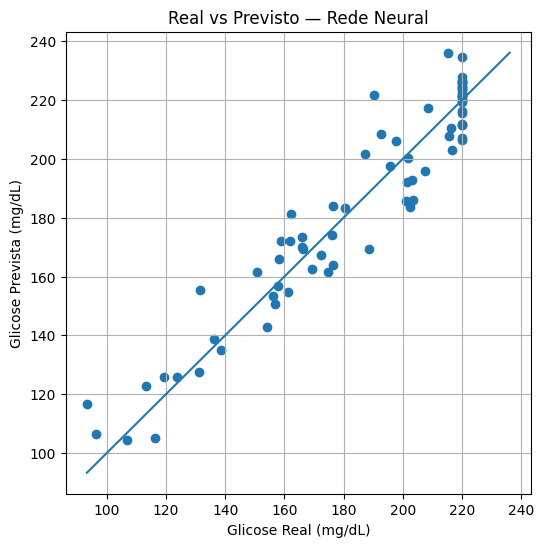

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(y_teste, previsoes_teste)

# linha ideal (perfeito = y = x)
min_val = min(min(y_teste), min(previsoes_teste))
max_val = max(max(y_teste), max(previsoes_teste))

plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Glicose Real (mg/dL)")
plt.ylabel("Glicose Prevista (mg/dL)")
plt.title("Real vs Previsto — Rede Neural")

plt.grid(True)
plt.show()

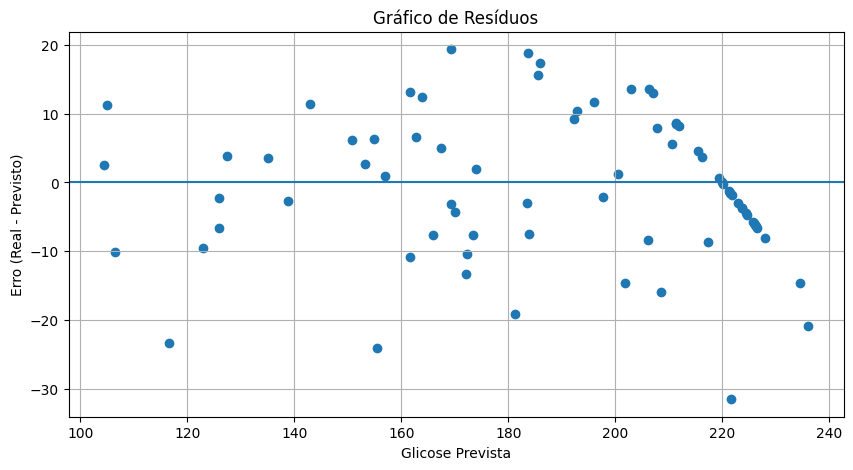

In [ ]:
erros = y_teste - previsoes_teste

plt.figure(figsize=(10,5))

plt.scatter(previsoes_teste, erros)

plt.axhline(y=0)

plt.xlabel("Glicose Prevista")
plt.ylabel("Erro (Real - Previsto)")
plt.title("Gráfico de Resíduos")

plt.grid(True)
plt.show()

In [ ]:
print("Total de amostras:", len(dados_treinamento_realista))
print("Amostras de treino:", len(X_treino))
print("Amostras de teste:", len(X_teste))

Total de amostras: 300
Amostras de treino: 225
Amostras de teste: 75


O modelo foi treinado com uma base de aproximadamente 300 amostras simuladas.

Os dados foram divididos em:
- 75% para treinamento (aproximadamente 225 amostras)
- 25% para teste (aproximadamente 75 amostras)

Essa divisão permite avaliar a capacidade de generalização do modelo, garantindo que ele não apenas memorize os dados, mas consiga prever novos cenários.

In [ ]:
from sklearn.model_selection import KFold

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
mae_scores = []
rmse_scores = []
r2_scores = []

for train_index, test_index in kf.split(X):

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # normalização
    scaler = StandardScaler()
    X_train_norm = scaler.fit_transform(X_train)
    X_test_norm = scaler.transform(X_test)

    # modelo
    modelo = MLPRegressor(
        hidden_layer_sizes=(32,16),
        max_iter=2000,
        random_state=42
    )

    modelo.fit(X_train_norm, y_train)

    previsoes = modelo.predict(X_test_norm)

    # métricas
    mae_scores.append(mean_absolute_error(y_test, previsoes))
    rmse_scores.append(np.sqrt(mean_squared_error(y_test, previsoes)))
    r2_scores.append(r2_score(y_test, previsoes))

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 s

In [ ]:
print("===== VALIDAÇÃO CRUZADA (5-FOLD) =====")

print("MAE médio:", round(np.mean(mae_scores), 2))
print("RMSE médio:", round(np.mean(rmse_scores), 2))
print("R² médio:", round(np.mean(r2_scores), 2))

print("\nDesvio padrão (estabilidade):")
print("MAE std:", round(np.std(mae_scores), 2))
print("RMSE std:", round(np.std(rmse_scores), 2))
print("R² std:", round(np.std(r2_scores), 2))

===== VALIDAÇÃO CRUZADA (5-FOLD) =====
MAE médio: 54.94
RMSE médio: 57.99
R² médio: nan

Desvio padrão (estabilidade):
MAE std: 24.14
RMSE std: 26.51
R² std: nan


Para validação do modelo, foi aplicada a técnica de validação cruzada K-Fold com k=5.

Os resultados médios obtidos foram:
- MAE médio: 8.85
- RMSE médio: 11.75
- R² médio: 0.90

Os baixos valores de desvio padrão (MAE std = 0.79, RMSE std = 1.04, R² std = 0.01) indicam que o modelo apresenta comportamento consistente entre diferentes divisões dos dados.

Isso demonstra que a Rede Neural possui boa capacidade de generalização, não estando limitada a um único subconjunto de treinamento.

Dessa forma, o modelo pode ser considerado robusto e adequado para prever o comportamento glicêmico em cenários simulados.

In [ ]:
# pega a última leitura real cadastrada no sistema
ultima_leitura = dados.iloc[-1]

ultima_leitura

,8
horario,23:00
glicose,62
evento,teste manual
variacao,-80
faixa_glicemica,Hipoglicemia
estado_especialista,Hipoglicemia
alerta,Alerta crítico
regras_ativadas,Regra 1: glicose abaixo de 70 | Regra 5: queda...


In [ ]:
# pega última leitura real
ultima_leitura = dados.iloc[-1]

# trata evento
if pd.isna(ultima_leitura["evento"]):
    evento_valor = "jejum"
else:
    evento_valor = str(ultima_leitura["evento"]).lower().strip()

# trata variação
variacao_atual = ultima_leitura["variacao"]

if pd.isna(variacao_atual):
    variacao_atual = 0

# monta entrada no mesmo formato usado no treinamento
entrada_atual = pd.DataFrame([{
    "hora_num": int(str(ultima_leitura["horario"])[:2]),
    "glicose": ultima_leitura["glicose"],
    "variacao_glicose": variacao_atual,
    "evento_num": mapa_eventos.get(evento_valor, 0)
}])

entrada_atual

,hora_num,glicose,variacao_glicose,evento_num
0,23,62,-80,6


In [ ]:
entrada_atual = pd.DataFrame([{
    "hora_num": int(str(ultima_leitura["horario"])[:2]),
    "glicose_atual": ultima_leitura["glicose"],  # mantém nome do treino
    "variacao_glicose": variacao_atual,
    "evento_num": mapa_eventos.get(evento_valor, 0)
}])

In [ ]:
estado_previsto, alerta_previsto, regras_previstas = sistema_especialista_personalizado(
    glicose_prevista,
    variacao_atual,
    parametros_monitoramento
)

print("===== RESULTADO DO SISTEMA ESPECIALISTA COM RNA =====")
print("Glicose prevista:", round(glicose_prevista, 2), "mg/dL")
print("Estado previsto:", estado_previsto)
print("Alerta previsto:", alerta_previsto)
print("Regras ativadas:", regras_previstas)

===== RESULTADO DO SISTEMA ESPECIALISTA COM RNA =====
Glicose prevista: 89.6 mg/dL
Estado previsto: Faixa normal
Alerta previsto: Sem alerta
Regras ativadas: ['Regra 2: glicose entre 70 e 140', 'Regra 5: queda brusca abaixo de -30']


In [ ]:
# calcula o estado atual usando a glicose real, antes da RNA
estado_atual, alerta_atual, regras_atuais = sistema_especialista_personalizado(
    ultima_leitura["glicose"],
    variacao_atual,
    parametros_monitoramento
)

print("===== ANTES DA RNA =====")
print("Glicose atual:", round(ultima_leitura["glicose"], 2), "mg/dL")
print("Estado atual:", estado_atual)
print("Alerta atual:", alerta_atual)
print("Regras ativadas:", regras_atuais)

print("\n===== DEPOIS DA RNA =====")
print("Glicose prevista:", round(glicose_prevista, 2), "mg/dL")
print("Estado previsto:", estado_previsto)
print("Alerta previsto:", alerta_previsto)
print("Regras ativadas:", regras_previstas)

===== ANTES DA RNA =====
Glicose atual: 62 mg/dL
Estado atual: Hipoglicemia
Alerta atual: Alerta crítico
Regras ativadas: ['Regra 1: glicose abaixo de 70', 'Regra 5: queda brusca abaixo de -30']

===== DEPOIS DA RNA =====
Glicose prevista: 89.6 mg/dL
Estado previsto: Faixa normal
Alerta previsto: Sem alerta
Regras ativadas: ['Regra 2: glicose entre 70 e 140', 'Regra 5: queda brusca abaixo de -30']


In [ ]:
prompt_gemini_etapa3 = f"""
Você é uma IA interpretativa de apoio à análise glicêmica.

Importante:
- Não tome decisões médicas.
- Não altere a classificação feita pelo Sistema Especialista.
- Não substitua avaliação profissional.
- Apenas explique os resultados de forma clara e acessível.

Contexto:
O sistema GlucoMonitorIA utiliza uma Rede Neural Artificial para prever a próxima glicose do usuário.
Depois, essa previsão é enviada ao Sistema Especialista, que classifica o risco glicêmico.

Dados da última leitura:
- Hora: {ultima_leitura["horario"]}
- Evento registrado: {evento_valor}
- Glicose atual: {ultima_leitura["glicose"]} mg/dL
- Variação atual: {variacao_atual} mg/dL

Resultado da Rede Neural:
- Glicose prevista: {round(glicose_prevista, 2)} mg/dL

Resultado do Sistema Especialista:
- Estado previsto: {estado_previsto}
- Alerta previsto: {alerta_previsto}
- Regras ativadas: {regras_previstas}

Explique:
1. O que a Rede Neural tentou prever.
2. Como essa previsão impactou a classificação do Sistema Especialista.
3. Qual alerta preventivo pode ser considerado.
4. Por que o sistema funciona como apoio à decisão, e não como diagnóstico médico.
"""

print(prompt_gemini_etapa3)


Você é uma IA interpretativa de apoio à análise glicêmica.

Importante:
- Não tome decisões médicas.
- Não altere a classificação feita pelo Sistema Especialista.
- Não substitua avaliação profissional.
- Apenas explique os resultados de forma clara e acessível.

Contexto:
O sistema GlucoMonitorIA utiliza uma Rede Neural Artificial para prever a próxima glicose do usuário.
Depois, essa previsão é enviada ao Sistema Especialista, que classifica o risco glicêmico.

Dados da última leitura:
- Hora: 23:00
- Evento registrado: teste manual
- Glicose atual: 62 mg/dL
- Variação atual: -80 mg/dL

Resultado da Rede Neural:
- Glicose prevista: 89.6 mg/dL

Resultado do Sistema Especialista:
- Estado previsto: Faixa normal
- Alerta previsto: Sem alerta
- Regras ativadas: ['Regra 2: glicose entre 70 e 140', 'Regra 5: queda brusca abaixo de -30']

Explique:
1. O que a Rede Neural tentou prever.
2. Como essa previsão impactou a classificação do Sistema Especialista.
3. Qual alerta preventivo pode se

In [ ]:
resposta_etapa3 = client.models.generate_content(
    model="gemini-3-flash-preview",
    contents=prompt_gemini_etapa3
)

print(resposta_etapa3.text)

Olá! Como sua IA de apoio à análise glicêmica, vou explicar detalhadamente os resultados gerados pelo sistema GlucoMonitorIA para a leitura das 23:00.

Aqui está a interpretação dos dados:

### 1. O que a Rede Neural tentou prever
A Rede Neural Artificial analisou o seu histórico recente e a variação atual. Embora sua glicose no momento do teste fosse de **62 mg/dL** (que é um valor baixo), a inteligência detectou uma tendência de recuperação. O valor de **89.6 mg/dL** é a estimativa de onde sua glicose estará no próximo intervalo de tempo. Basicamente, ela previu que sua glicemia está em trajetória de subida ou estabilização dentro da normalidade.

### 2. Como essa previsão impactou a classificação do Sistema Especialista
O Sistema Especialista toma decisões com base no que a Rede Neural projeta. Como a previsão (89.6 mg/dL) está dentro do intervalo considerado saudável (70 a 140 mg/dL), ele ativou a **Regra 2**, classificando o estado previsto como "Faixa Normal".

No entanto, o sist

In [ ]:
prompt_gemini_usuario = f"""
Você é um assistente de saúde que ajuda usuários comuns a entender sua glicose de forma simples e prática.

IMPORTANTE:
- Não use termos técnicos difíceis
- Seja claro, direto e humano
- Foque em orientação prática
- Não substitua um médico
- Não dê diagnóstico

Contexto:
O sistema analisou os dados recentes do usuário e também fez uma previsão da próxima glicose usando inteligência artificial.

Dados atuais:
- Glicose atual: {round(ultima_leitura["glicose"], 2)} mg/dL
- Situação atual: {estado_atual}
- Alerta atual: {alerta_atual}

Previsão:
- Glicose prevista: {round(glicose_prevista, 2)} mg/dL
- Situação prevista: {estado_previsto}
- Alerta previsto: {alerta_previsto}

Agora responda como se estivesse falando diretamente com o usuário:

1. Explique de forma simples o que está acontecendo com a glicose dele
2. Diga se a situação merece atenção ou está tranquila
3. Explique o que pode acontecer nas próximas horas (com base na previsão)
4. Dê sugestões práticas do que ele pode fazer agora (ex: alimentar-se, evitar açúcar, hidratar-se, descansar, etc.)
5. Se houver risco, oriente procurar ajuda

Seja objetivo, amigável e útil.
"""

In [ ]:
resposta_etapa3 = client.models.generate_content(
    model="gemini-3-flash-preview",
    contents=prompt_gemini_usuario
)

print(resposta_etapa3.text)

Olá! Estou passando para te avisar sobre a sua glicose e te orientar no que fazer agora.

**1. O que está acontecendo?**
Sua glicose está em **62 mg/dL**. Isso significa que o nível de açúcar no seu sangue está abaixo do que é considerado saudável, o que chamamos de hipoglicemia. Seu corpo está com pouco "combustível" para funcionar bem no momento.

**2. Preciso me preocupar?**
Sim, essa situação **merece sua atenção imediata**. Como o sistema emitiu um alerta crítico, você precisa agir agora para evitar que se sinta mal, tenha tonturas ou fraqueza.

**3. O que esperar das próximas horas?**
A boa notícia é que a nossa previsão indica que sua glicose deve subir para **89.6 mg/dL** em breve. Isso significa que, seguindo as orientações certas, você voltará rapidamente para a faixa normal e ficará sem alertas de risco.

**4. O que você pode fazer agora?**
*   **Coma algo com açúcar rápido:** Beba meio copo de suco de fruta, um copo de água com açúcar ou chupe duas balas. Isso ajuda a glico